In [12]:
import math
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

In [13]:
# ──────────────────────────────────────────────
#  ФУНКЦИИ И ЕЕ ПРОИЗВОДНЫЕ
# ──────────────────────────────────────────────

def f(x):
    """f(x) = 2·lg(x) - x/2 + 1"""
    return 2.0 * math.log10(x) - x / 2.0 + 1.0


def f_prime(x):
    """f'(x) = 2/(x·ln10) - 1/2"""
    return 2.0 / (x * math.log(10)) - 1.0 / 2.0


def f_double_prime(x):
    """f''(x) = -2/(x²·ln10)"""
    return -2.0 / (x ** 2 * math.log(10))

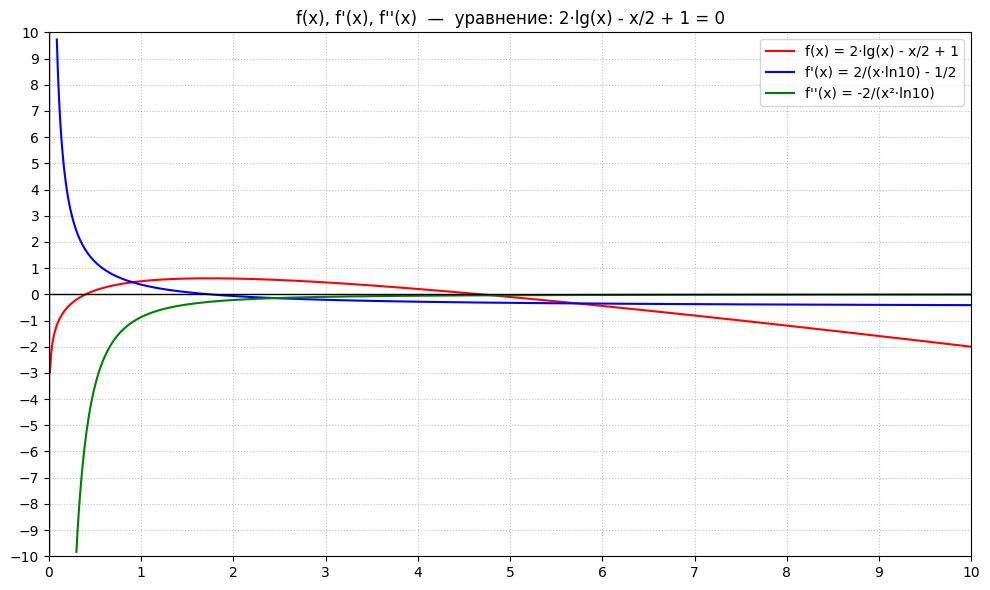

In [14]:
plt.figure(figsize=(10, 6))

n = 800
a, b = 0.01, 10.0  # область определения: x > 0
xs = [a + i * (b - a) / n for i in range(n + 1)]

for func, color, label in [
    (f,              'red',   "f(x) = 2·lg(x) - x/2 + 1"),
    (f_prime,        'blue',  "f'(x) = 2/(x·ln10) - 1/2"),
    (f_double_prime, 'green', "f''(x) = -2/(x²·ln10)"),
]:
    ys = [func(x) if abs(func(x)) <= 10 else None for x in xs]
    plt.plot(xs, ys, color=color, label=label)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.8)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(1))
plt.xlim(0, 10)
plt.ylim(-10, 10)
plt.title("f(x), f'(x), f''(x)  —  уравнение: 2·lg(x) - x/2 + 1 = 0")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ──────────────────────────────────────────────
#  ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ──────────────────────────────────────────────
def separate_roots(x_min=0.01, x_max=16.0, step=0.05):
    intervals = []
    prev_x, prev_fx = None, None
    x = x_min
    while x <= x_max:
        # 0.15 взят экспериментально, чтобы не пропустить корни, близкие к этим точками
        k = round(x / math.pi)
        if abs(x - k * math.pi) < 0.15:
            x += step
            prev_x = prev_fx = None
            continue
        fx = f(x)

        # Если функция меняет знак, значит в этом интервале есть корни. Запоминаем его
        if prev_fx is not None and prev_fx * fx < 0:
            intervals.append((round(prev_x, 4), round(x, 4)))
        
        # Cохраняем текущее значение для следующей итерации
        prev_x, prev_fx = x, fx
        x = round(x + step, 6)
    return intervals

Видео по которому взял теорию <br/>
https://youtu.be/BaLwroc_cbY?si=qbG0GqQtJIQCvZt_<br/>
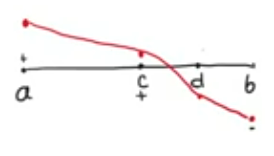

In [16]:
# ──────────────────────────────────────────────
#  1. МЕТОД ДИХОТОМИИ
# ──────────────────────────────────────────────
def dichotomy(a, b, eps=1e-4):
    """
    Метод деления пополам
    Начальное приближение: выбрать [a, b] так, чтобы f(a)·f(b) < 0
    Остановка: (b - a) / 2 < eps
    """
    # a и b должны быть разного знака
    if f(a) * f(b) >= 0:
        raise ValueError(f"f(a)·f(b) > 0 на [{a}, {b}] — корень не гарантирован.")
    
    # Счетчик количества итераций
    n = 0

    # Считаем до тех пор, пока длина интервала не станет меньше 2·eps
    # Когда (b - a) / 2 < eps, значит коренем будет являтся серединой интервала [a, b]
    while (b - a) / 2.0 > eps:
        # Находим половину промежутка и значение функции в этой точке
        c = (a + b) / 2.0
        fc = f(c)

        # Если f(a)·f(c) ≤ 0  →  корень на [a, c]  →  b = c
        # Если f(a)·f(c) > 0  →  корень на [c, b]  →  a = c
        if f(a) * fc <= 0:
            b = c
        else:
            a = c

        n += 1
    
    root = (a + b) / 2.0

    return root, n


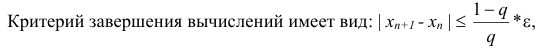 <br/>
Видео по которому взял теорию <br/>
https://youtu.be/hAAJ6G8zzjM?si=Xer7CGxb24LCd746

In [17]:
# ──────────────────────────────────────────────
#  2. МЕТОД ПРОСТОЙ ИТЕРАЦИИ
# ──────────────────────────────────────────────

def simple_iteration(x0, eps=1e-4):
    """
    Метод простой итерации

    Уравнение: 2 * lg(x) - x/2 + 1 = 0
    Преобразуем к виду x = φ(x):
    
    В таком случае первый корень не сходится, a второй наоборот 
    x/2 = 2 * lg(x) + 1
    x = 4 * lg(x) + 2
    φ(x) = 4 * log10(x) + 2  →  x_{n+1} = φ(x_n)

    В таком случае второй корень не сходится, а первый наоборот
    2 · lg(x) = x/2 - 1  
    x = 10^(0.25x - 0.5)
    φ(x) = 10^(0.25x - 0.5)  →  x_{n+1} = φ(x_n)
    
    **поделить пополам как вариант**

    Остановка: |x_{n+1} - x_n| < eps

    **релаксация**

    """
 
    def phi(x):
        if x < 2:
            # Малый корень
            return math.pow(10, 0.25 * x - 0.5)
        else:
            # Больший корень
            return 4.0 * math.log10(x) + 2.0
 
    # Предполагаемый корень
    x = x0
    # Счетчик количества итераций
    n = 0
    while n < 500:
        xn = phi(x)
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1
 
    return x, n

https://youtu.be/sdsKWK0_TIs?si=uOkxKrv9Ri7626s_<br/>
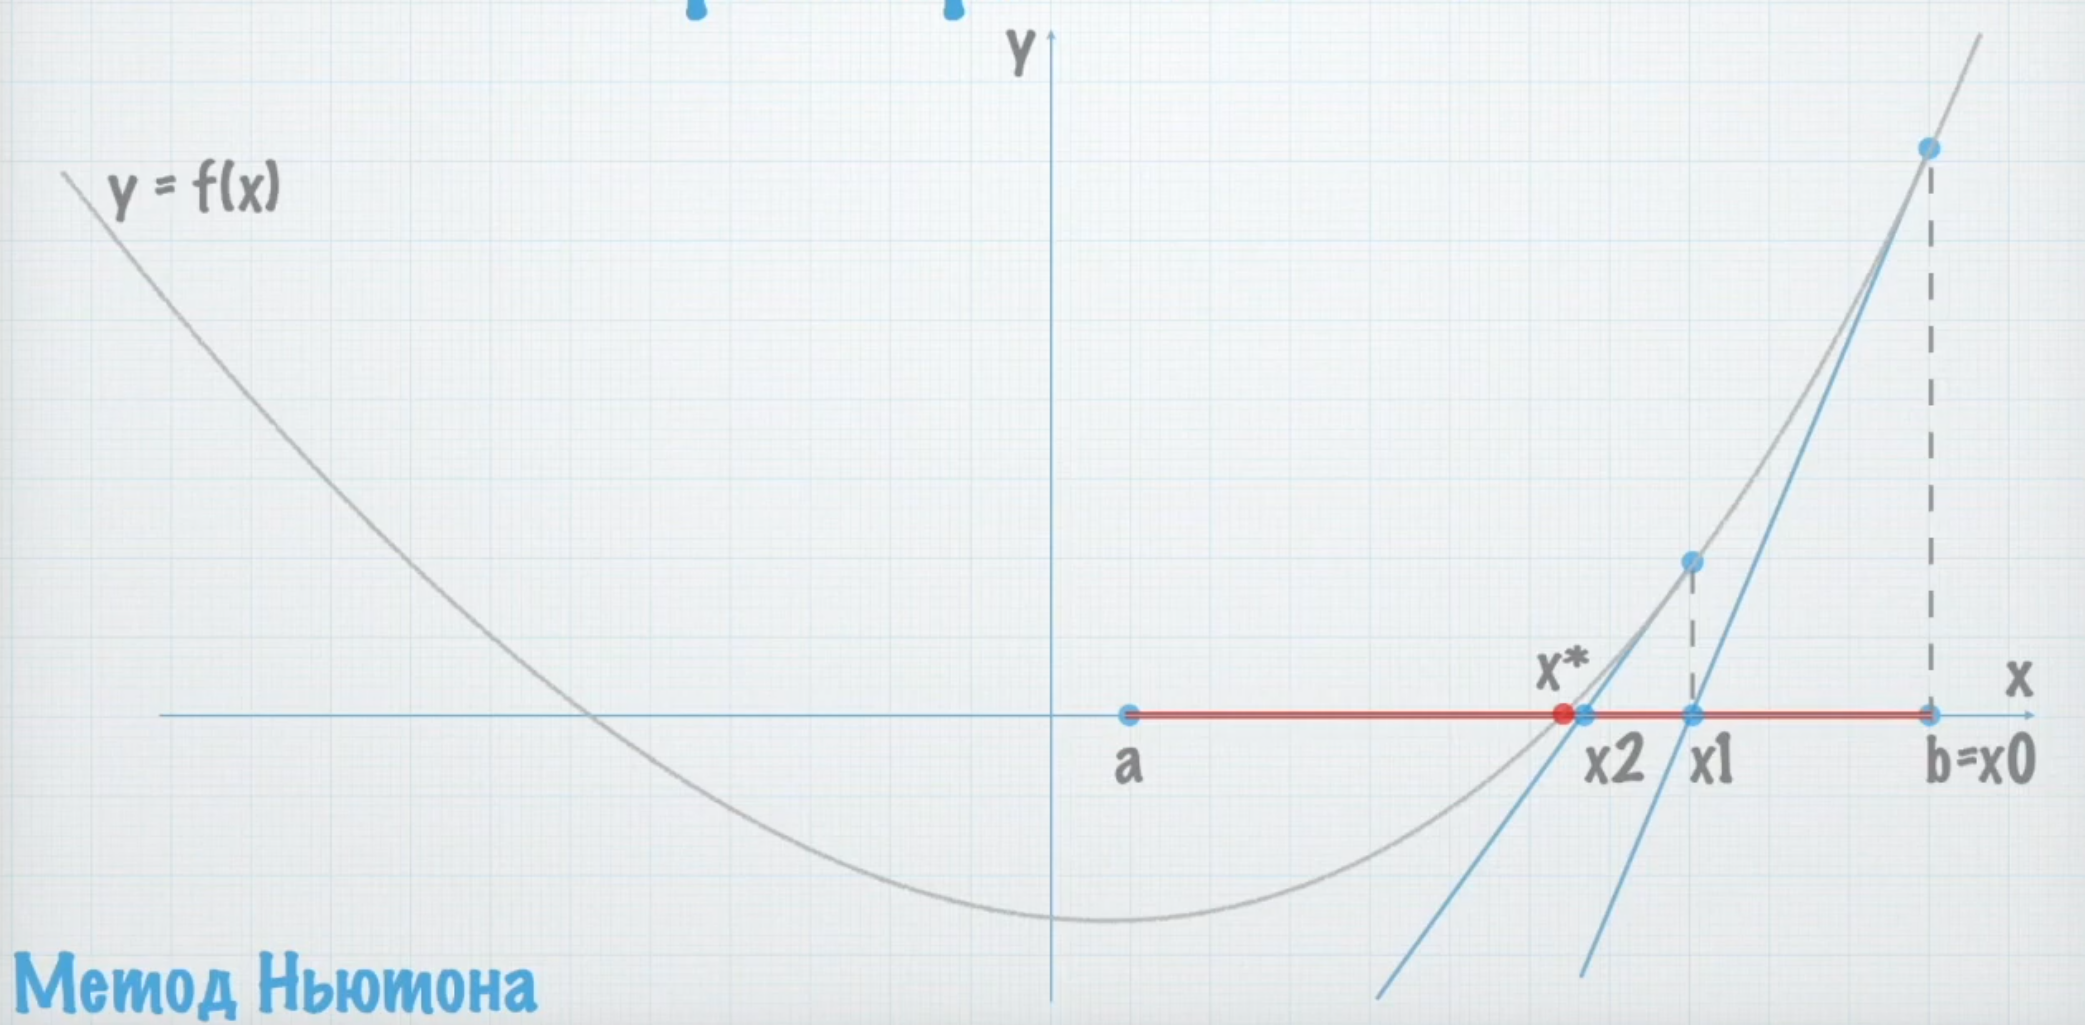

In [18]:
# ──────────────────────────────────────────────
#  3. МЕТОД НЬЮТОНА (КАСАТЕЛЬНЫХ)
# ──────────────────────────────────────────────

def newton(x0, eps=1e-4):
    """
    Метод Ньютона
    
    x_{n+1} = x_n - f(x_n) / f'(x_n)
    Остановка: |x_{n+1} - x_n| < eps.
    """

    x = x0
    n = 0
    while n < 50:
        fx = f(x)   
        fpx = f_prime(x)
        if abs(fpx) < 1e-14:
            print(f"(x) ≈ 0, метод Ньютона не применим")
            break
        xn = x - fx / fpx
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1

    return x, n


https://youtu.be/cdtSqwwx-yQ?si=EJXDWI7jBfiEzOMf<br/>
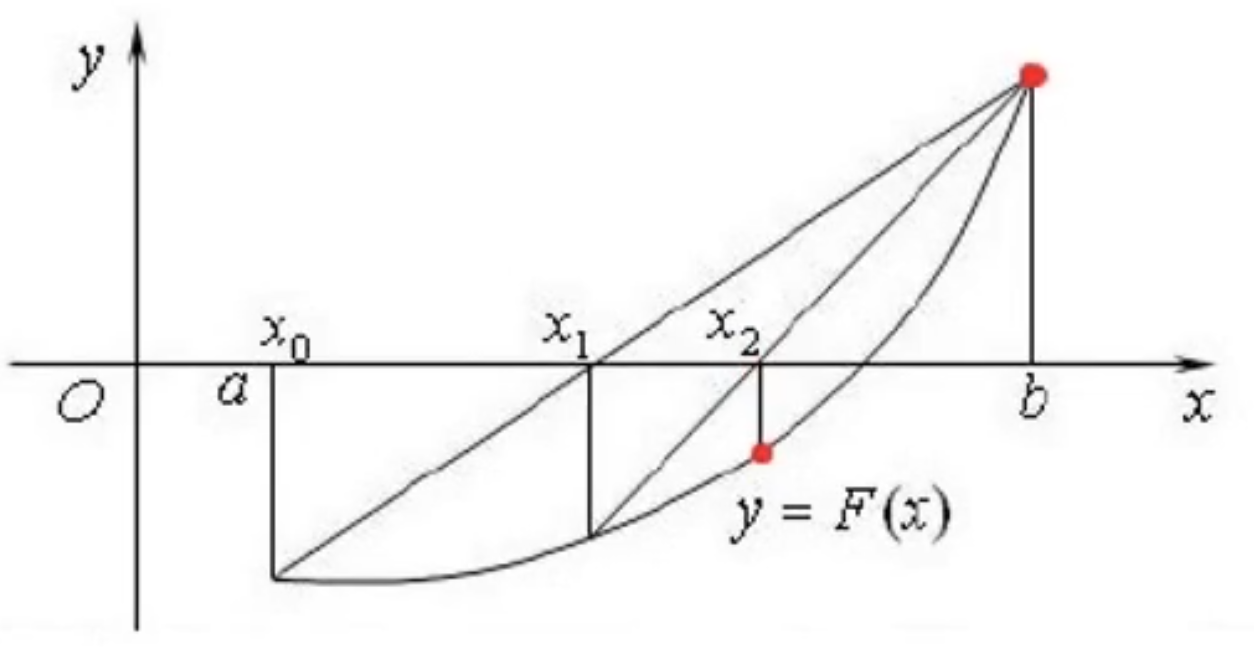

In [19]:
# ──────────────────────────────────────────────
#  4. МЕТОД ХОРД (СЕКУЩИХ)
# ──────────────────────────────────────────────

def chord(a, b, eps=1e-4):
    """
    Метод хорд
    Фиксируем конец, где f·f'' > 0; подвижный конец сходится к корню
    Остановка: |f(c)| < eps
    """
    if f(a) * f(b) > 0:
        raise ValueError(f"f(a)·f(b) > 0 на [{a}, {b}].")

    # определяем фиксированный конец
    fix_a = f(a) * f_double_prime(a) > 0

    n = 0
    while n < 200:
        fa, fb = f(a), f(b)
        c = a - fa * (b - a) / (fb - fa)
        fc = f(c)
        if abs(fc) < eps:
            n += 1
            break
        if fix_a:
            if fc * fa < 0:
                b = c
            else:
                a = c
        else:
            if fc * fb < 0:
                a = c
            else:
                b = c
        n += 1

    root = a - f(a) * (b - a) / (f(b) - f(a))

    return root, n

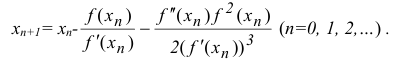

In [20]:
# ──────────────────────────────────────────────
#  5. МЕТОД ЧЕБЫШЕВА
# ──────────────────────────────────────────────

def chebyshev(x0, eps=1e-4):
    """
    Метод Чебышева
    x_{n+1} = x_n - f/f' - (f²·f'') / (2·(f')³)
    Остановка: |x_{n+1} - x_n| < eps
    """

    x = x0
    n = 0
    while n < 30:
        fx = f(x)
        fpx = f_prime(x)
        fppx = f_double_prime(x)
        xn = x - fx / fpx - (fx ** 2 * fppx) / (2.0 * fpx ** 3)
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1

    return x, n

In [21]:
# ──────────────────────────────────────────────
#  ГЛАВНАЯ ПРОГРАММА
# ──────────────────────────────────────────────
def main():
    EPS = 1e-4

    # ── Шаг 1: отделение корней ───────────────────
    print("\n" + "=" * 60)
    print("  f(x) = 2·lg(x) - x/2 + 1 = 0")
    print("=" * 60)
    intervals = separate_roots()
    print(f"  Найдено интервалов со сменой знака: {len(intervals)}")
    print(f"\n  {'Интервал':<20} {'f(a)':>10} {'f(b)':>10}")
    print("  " + "-" * 42)
    for a, b in intervals:
        print(f"  [{a:.4f}, {b:.4f}]{'':<4} {f(a):>10.4f} {f(b):>10.4f}")

    if len(intervals) < 2:
        print("Недостаточно интервалов!")
        return

    a1, b1 = intervals[0]
    a2, b2 = intervals[1]
    x01 = (a1 + b1) / 2
    x02 = (a2 + b2) / 2
    print(f"\n  Уточняем корень 1 на [{a1:.4f}, {b1:.4f}]  (x₀ = {x01:.4f})")
    print(f"  Уточняем корень 2 на [{a2:.4f}, {b2:.4f}]  (x₀ = {x02:.4f})")

    # ── Шаг 2: корень 1 ───────────────────────────
    print("\n" + "=" * 60)
    print("  КОРЕНЬ 1")
    print("=" * 60)
    print(f"  {'Метод':<22} {'Результат'}")
    print("  " + "-" * 56)

    r1_d,  n1_d  = dichotomy(a1, b1, EPS)
    try:
        r1_i,  n1_i  = simple_iteration(x01, EPS)
    except ValueError as e:
        print(f"  Простая итерация: Ошибка ({e})")
        r1_i, n1_i = float('nan'), 0 
    r1_n,  n1_n  = newton(x01, EPS)
    r1_c,  n1_c  = chord(a1, b1, EPS)
    r1_ch, n1_ch = chebyshev(x01, EPS)

    print(f"  {'Дихотомия':<22} корень = {r1_d:.6f},  итераций = {n1_d:>3},  |f(x*)| = {abs(f(r1_d)):.2e}")
    print(f"  {'Простая итерация':<22} корень = {r1_i:.6f},  итераций = {n1_i:>3},  |f(x*)| = {abs(f(r1_i)):.2e}")
    print(f"  {'Метод Ньютона':<22} корень = {r1_n:.6f},  итераций = {n1_n:>3},  |f(x*)| = {abs(f(r1_n)):.2e}")
    print(f"  {'Метод хорд':<22} корень = {r1_c:.6f},  итераций = {n1_c:>3},  |f(x*)| = {abs(f(r1_c)):.2e}")
    print(f"  {'Метод Чебышева':<22} корень = {r1_ch:.6f},  итераций = {n1_ch:>3},  |f(x*)| = {abs(f(r1_ch)):.2e}")

    # ── Шаг 3: корень 2 ───────────────────────────
    print("\n" + "=" * 60)
    print("  КОРЕНЬ 2")
    print("=" * 60)
    print(f"  {'Метод':<22} {'Результат'}")
    print("  " + "-" * 56)

    r2_d,  n2_d  = dichotomy(a2, b2, EPS)
    try:
        r2_i,  n2_i  = simple_iteration(x02, EPS)
    except ValueError as e:
        print(f"  Простая итерация: Ошибка ({e})")
        r2_i, n2_i = float('nan'), 0 
    r2_n,  n2_n  = newton(x02, EPS)
    r2_c,  n2_c  = chord(a2, b2, EPS)
    r2_ch, n2_ch = chebyshev(x02, EPS)

    print(f"  {'Дихотомия':<22} корень = {r2_d:.6f},  итераций = {n2_d:>3},  |f(x*)| = {abs(f(r2_d)):.2e}")
    print(f"  {'Простая итерация':<22} корень = {r2_i:.6f},  итераций = {n2_i:>3},  |f(x*)| = {abs(f(r2_i)):.2e}")
    print(f"  {'Метод Ньютона':<22} корень = {r2_n:.6f},  итераций = {n2_n:>3},  |f(x*)| = {abs(f(r2_n)):.2e}")
    print(f"  {'Метод хорд':<22} корень = {r2_c:.6f},  итераций = {n2_c:>3},  |f(x*)| = {abs(f(r2_c)):.2e}")
    print(f"  {'Метод Чебышева':<22} корень = {r2_ch:.6f},  итераций = {n2_ch:>3},  |f(x*)| = {abs(f(r2_ch)):.2e}")

    print("\n" + "=" * 60)
        # ── Шаг 4: проверка корректности ─────────────


    print("\n  Критерий: корень принят, если |f(x*)| < EPS = {:.0e}".format(EPS))
    print("\n  Корень 1:")
    for name, root in [("Дихотомия", r1_d), ("Простая итерация", r1_i),
                        ("Метод Ньютона", r1_n), ("Метод хорд", r1_c), ("Метод Чебышева", r1_ch)]:
        status = "✓" if abs(f(root)) < EPS else "✗"
        print(f"    {name:<22} |f(x*)| = {abs(f(root)):.2e}  →  {status}")

    print("\n  Корень 2:")
    for name, root in [("Дихотомия", r2_d), ("Простая итерация", r2_i),
                        ("Метод Ньютона", r2_n), ("Метод хорд", r2_c), ("Метод Чебышева", r2_ch)]:
        status = "✓" if abs(f(root)) < EPS else "✗"
        print(f"    {name:<22} |f(x*)| = {abs(f(root)):.2e}  →  {status}")

    print("\n" + "=" * 60)

if __name__ == "__main__":
    main()




  f(x) = 2·lg(x) - x/2 + 1 = 0
  Найдено интервалов со сменой знака: 2

  Интервал                   f(a)       f(b)
  ------------------------------------------
  [0.3600, 0.4100]        -0.0674     0.0206
  [4.6600, 4.7100]         0.0068    -0.0090

  Уточняем корень 1 на [0.3600, 0.4100]  (x₀ = 0.3850)
  Уточняем корень 2 на [4.6600, 4.7100]  (x₀ = 4.6850)

  КОРЕНЬ 1
  Метод                  Результат
  --------------------------------------------------------
  Дихотомия              корень = 0.397598,  итераций =   8,  |f(x*)| = 8.88e-05
  Простая итерация       корень = 0.397537,  итераций =   5,  |f(x*)| = 1.32e-05
  Метод Ньютона          корень = 0.397545,  итераций =   3,  |f(x*)| = 3.20e-14
  Метод хорд             корень = 0.397592,  итераций =   2,  |f(x*)| = 7.90e-05
  Метод Чебышева         корень = 0.397545,  итераций =   2,  |f(x*)| = 6.66e-16

  КОРЕНЬ 2
  Метод                  Результат
  --------------------------------------------------------
  Дихотомия        

# Преимущества
## Дихотомия
Если на концах начального отрезка функция имеет разные знаки, метод всегда найдет корень. Простой алгоритм
## Простая итерация 
На каждой итерации требуется только подстановка значения
## Метод Ньютона
Обладает квадратичной сходимостью. Требует меньше итераций для высокой точности
## Метод хорд
Не требует производной. Сходится быстрее метода дихотомии
## Метод Чебышева
Сверхвысокая скорость. Позволяет достигать высокой точности 
# Ограничения
## Дихотомия
Медленная сходимость. Необходим отрезок с разными знаками на концах
## Простая итерация
Часто сходится медленее метода Ньютона. Сходится только если в окрестности корня
## Метод Ньютона
Необходимо вычисление производной может расходиться 
## Метод хорд
Требует задания двух точек. Порядок сходимости ниже, чем у метода Ньютона
## Метод Чебышева
Требует вычисления и первой, и второй производной. 

In [22]:
def phi1_derivative(x: float) -> float:
    """
    φ₁(x) = 4·lg(x) + 2
    φ₁'(x) = 4 / (x · ln(10))
    """
    return 4.0 / (x * math.log(10))

def phi2_derivative(x: float) -> float:
    """
    φ₂(x) = 10^(0.25x - 0.5)
    φ₂'(x) = 10^(0.25x - 0.5) · ln(10) · 0.25
    """
    return math.pow(10, 0.25 * x - 0.5) * math.log(10) * 0.25



print("\n  Таблица значений производных:")
print("  " + "-" * 56)
print(f"  {'x':<8} {'φ₁':<12} {'φ₂':<12} {'Статус':<20}")
print("  " + "-" * 56)

test_points = [0.4, 1.0, 1.5, 2.0, 3.0, 4.8]

for x in test_points:
    d1 = phi1_derivative(x)
    d2 = phi2_derivative(x)
    
    # Проверка сходимости формулы
    status = []
    if d1 < 1:
        status.append("φ₁ ✓")
    else:
        status.append("φ₁ ✗")
    
    if d2 < 1:
        status.append("φ₂ ✓")
    else:
        status.append("φ₂ ✗")
    
    status_str = ", ".join(status)
    
    print(f"  {x:<8.2f} {d1:<12.4f} {d2:<12.4f} {status_str:<20}")


  Таблица значений производных:
  --------------------------------------------------------
  x        φ₁           φ₂           Статус              
  --------------------------------------------------------
  0.40     4.3429       0.2292       φ₁ ✗, φ₂ ✓          
  1.00     1.7372       0.3237       φ₁ ✗, φ₂ ✓          
  1.50     1.1581       0.4317       φ₁ ✗, φ₂ ✓          
  2.00     0.8686       0.5756       φ₁ ✓, φ₂ ✓          
  3.00     0.5791       1.0237       φ₁ ✓, φ₂ ✗          
  4.80     0.3619       2.8851       φ₁ ✓, φ₂ ✗          
